Preámbulo:

In [2]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn
from google.colab import files
from collections import Counter

seaborn.set_context('talk')

In [3]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)

#Ejercicio 1: Análisis descriptivo

##Selección de las columnas y filas relevantes para analizar.

Además de las columnas `tools_programming_languages` y `salary_monthly_NETO` se reealiza la siguiente selección de columnas:

`work_dedication`: se filtrará dedicación full-time \\
`seniority`: para distinguir categorias (junior/semi-senior/senior) \\
`salary_monthly_NETO`: se filtrarán sueldos mayores al mínimo vital y móvil y menores a valores que puedan considerarse atípicos
`profile_age` y `profile_years_experience`: para evaluar experiencia

#Reformulación de pregunta:
¿Cuáles son los lenguajes de programación que están asociados a los mejores salarios entre programadores con trabajo full-time y experiencia semi-senior o senior?”


In [8]:
relevant_columns = ['work_dedication',
                    'work_seniority',
                    'salary_monthly_NETO',
                    'tools_programming_languages',
                    'profile_studies_level']

df_filtered = df[
    (df['work_dedication'] == 'Full-Time') &
    (df['salary_monthly_NETO'].notna()) &
    (df['salary_monthly_NETO'] > 360000) &
    (df['salary_monthly_NETO'] < 7000000) &
    (df['tools_programming_languages'] != 'Ninguno de los anteriores')]


df_result = df_filtered[relevant_columns]

df_result[:]

,work_dedication,work_seniority,salary_monthly_NETO,tools_programming_languages,profile_studies_level
0,Full-Time,Senior,2400000.0,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",NaN
1,Full-Time,Senior,5000000.0,".NET, C#, HTML, Javascript, SQL",NaN
2,Full-Time,Senior,3600000.0,"Go, SQL",Universitario
4,Full-Time,Semi-Senior,3200000.0,"Bash/Shell, Python",NaN
7,Full-Time,Semi-Senior,6400000.0,"Go, PHP, Python, SQL",Universitario
...,...,...,...,...,...
4933,Full-Time,Semi-Senior,1200000.0,"Go, HTML, Javascript, SQL",NaN
4935,Full-Time,Junior,1000000.0,Python,NaN
4936,Full-Time,Semi-Senior,2908000.0,"Bash/Shell, HTML, Java, Javascript, PHP, Pytho...",NaN
4937,Full-Time,Senior,3400000.0,"Java, Javascript, SQL, TypeScript",Terciario


In [6]:
df_result["salary_monthly_NETO"].describe()

,salary_monthly_NETO
count,3.464000e+03
mean,2.982667e+06
std,1.391633e+06
min,3.690000e+05
25%,1.908099e+06
50%,2.748338e+06
75%,3.850000e+06
max,6.978667e+06


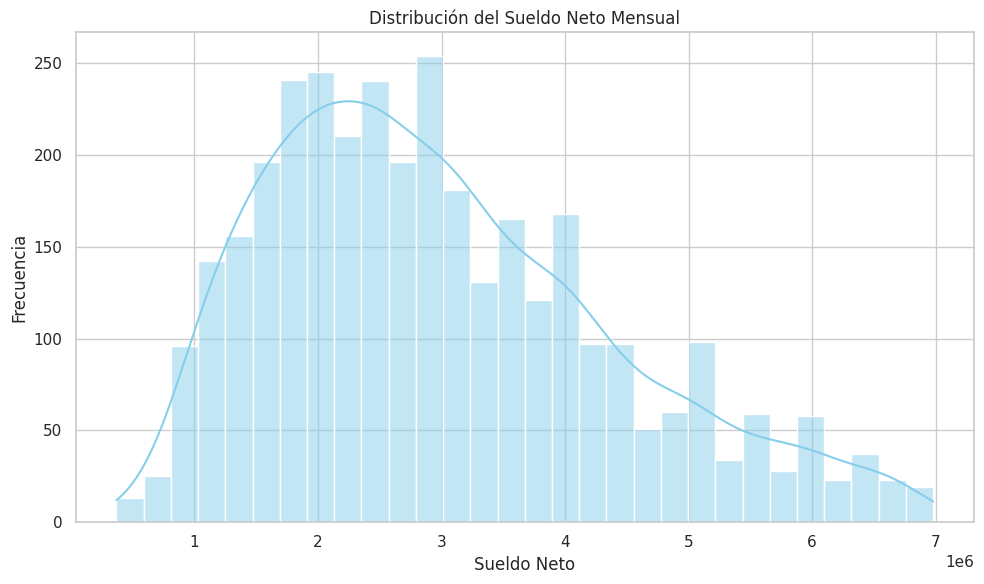

In [5]:
# Ajuste de estilo
seaborn.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Histograma del sueldo NETO
plt.figure()
seaborn.histplot(df_result["salary_monthly_NETO"], kde=True, bins=30, color='skyblue')
plt.title("Distribución del Sueldo Neto Mensual")
plt.xlabel("Sueldo Neto")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

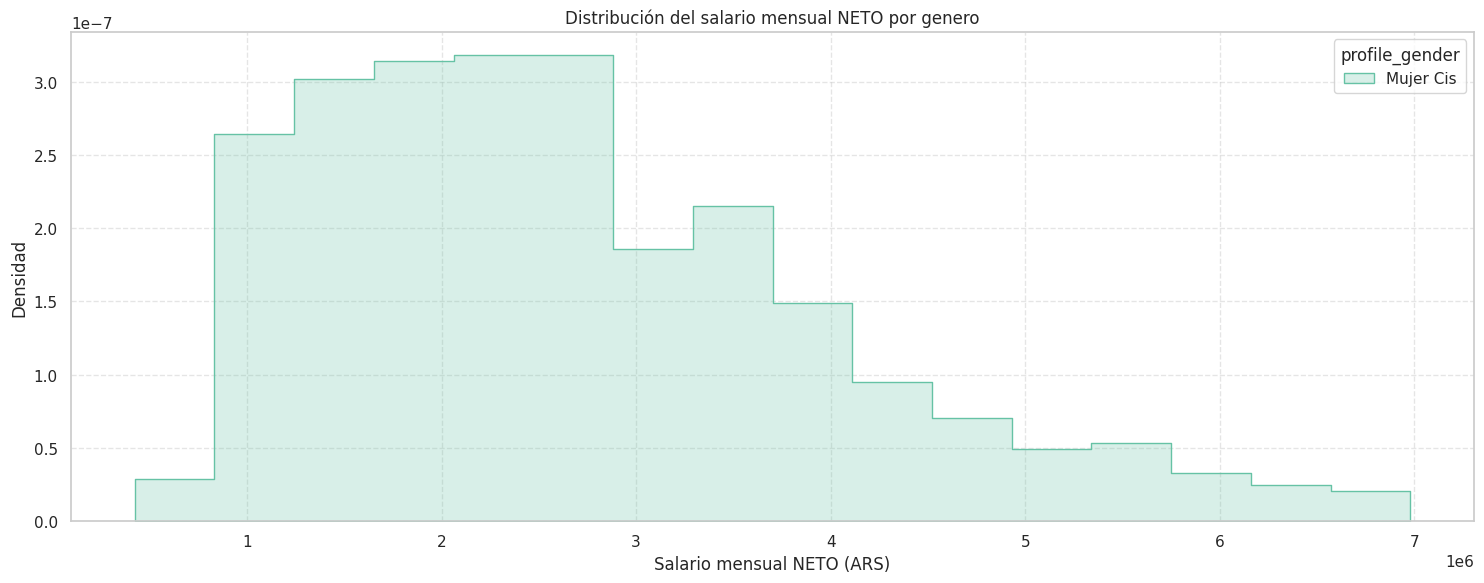

In [19]:
generos = ["Varón", "Mujer Cis"]  # cambiá estos valores según necesites

# Filtrado
df_generos = df_filtered[
    df_filtered["profile_gender"].isin(generos)
]

# 👉 Gráfico (igual al tuyo, pero con el df filtrado)
plt.figure(figsize=(15, 6))
seaborn.histplot(
    data=df_generos,
    x='salary_monthly_NETO',
    hue='profile_gender',
    element='step',
    stat='density',
    common_norm=False,
    palette='Set2'
)

plt.title('Distribución del salario mensual NETO por genero')
plt.xlabel('Salario mensual NETO (ARS)')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

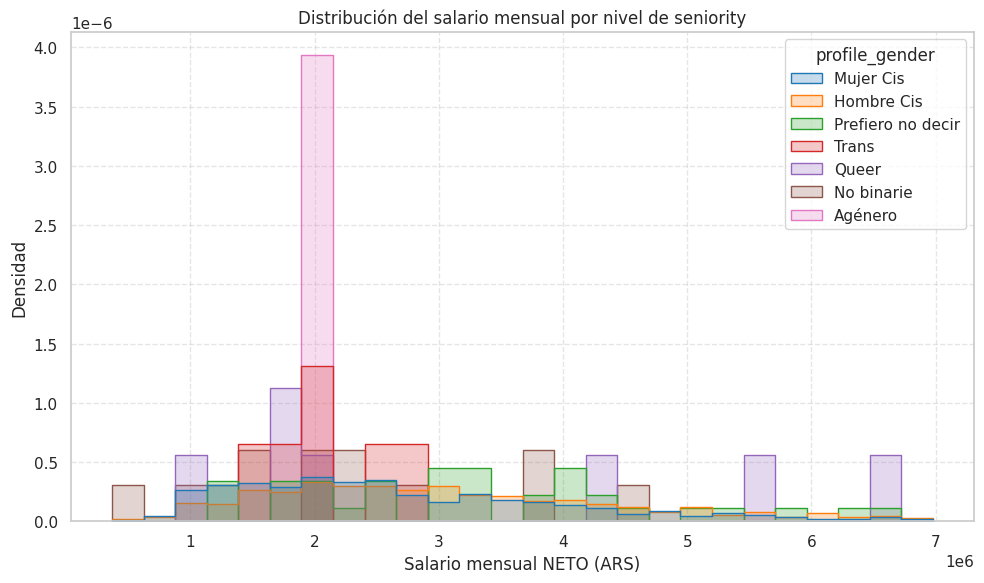

In [12]:
plt.figure(figsize=(10, 6))
seaborn.histplot(data=df_filtered, x='salary_monthly_NETO', hue='profile_gender', element='step', stat='density', common_norm=False, palette='tab10')
plt.title('Distribución del salario mensual por nivel de seniority')
plt.xlabel('Salario mensual NETO (ARS)')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_12974/931861277.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.barplot(x=list(lenguajes), y=list(frecuencias), palette='Set2', ax = ax1)


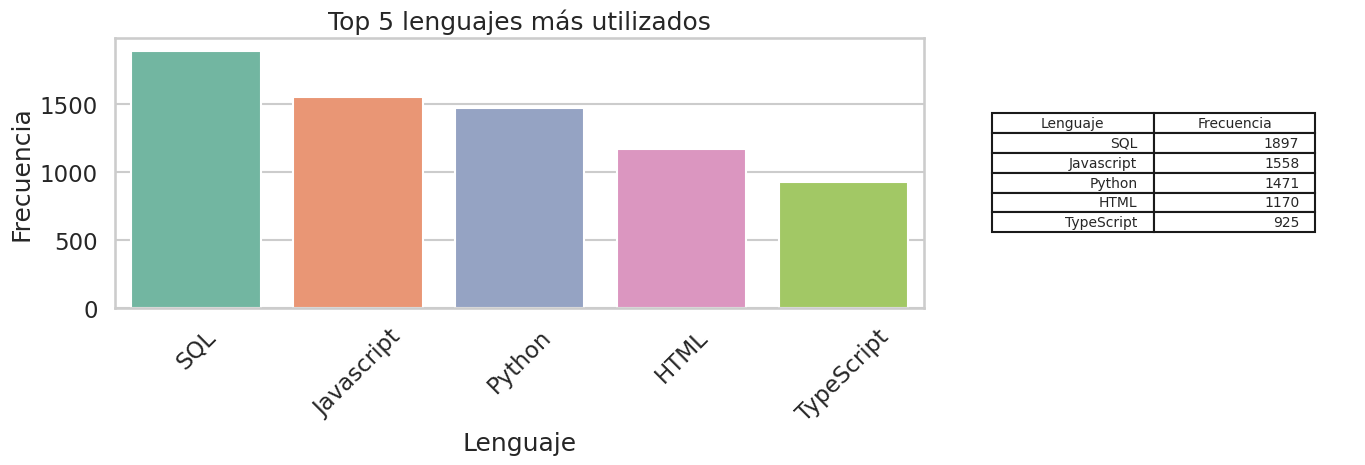

In [ ]:
# Unir todos los lenguajes en una sola lista
language_series = df_filtered['tools_programming_languages'].dropna().str.split(', ')
all_languages = [lang for sublist in language_series for lang in sublist]

# Contar
language_counts = Counter(all_languages)

# Mostrar los 10 lenguajes más comunes
top5 = language_counts.most_common(5)

# Separar en listas para graficar
lenguajes, frecuencias = zip(*top5)


# Crear figura con 2 subplots: gráfico + tabla
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [2, 1]})
# Crear gráfico
seaborn.barplot(x=list(lenguajes), y=list(frecuencias), palette='Set2', ax = ax1)


ax1.set_title('Top 5 lenguajes más utilizados')
ax1.set_xlabel('Lenguaje')
ax1.set_ylabel('Frecuencia')
ax1.tick_params(axis='x', rotation=45)

# Tabla
ax2.axis('off')
table_data = list(zip(lenguajes, frecuencias))
column_labels = ['Lenguaje', 'Frecuencia']
tabla = ax2.table(cellText=table_data, colLabels=column_labels, loc='center')
tabla.scale(0.8, 1.7)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)

plt.tight_layout()
plt.show()

Los datos observados en la tabla y gráfico de frecuencias corresponden a los 10 lenguajes más utilizados con un sueldo neto en pesos argentinos, entre el salario mínimo vital y móvil (\$ 360.000) y \$ 7.000.000

/tmp/ipykernel_12974/2687123349.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.boxplot(data=df_lang_salary, x='language', y='salary', palette='Set2')


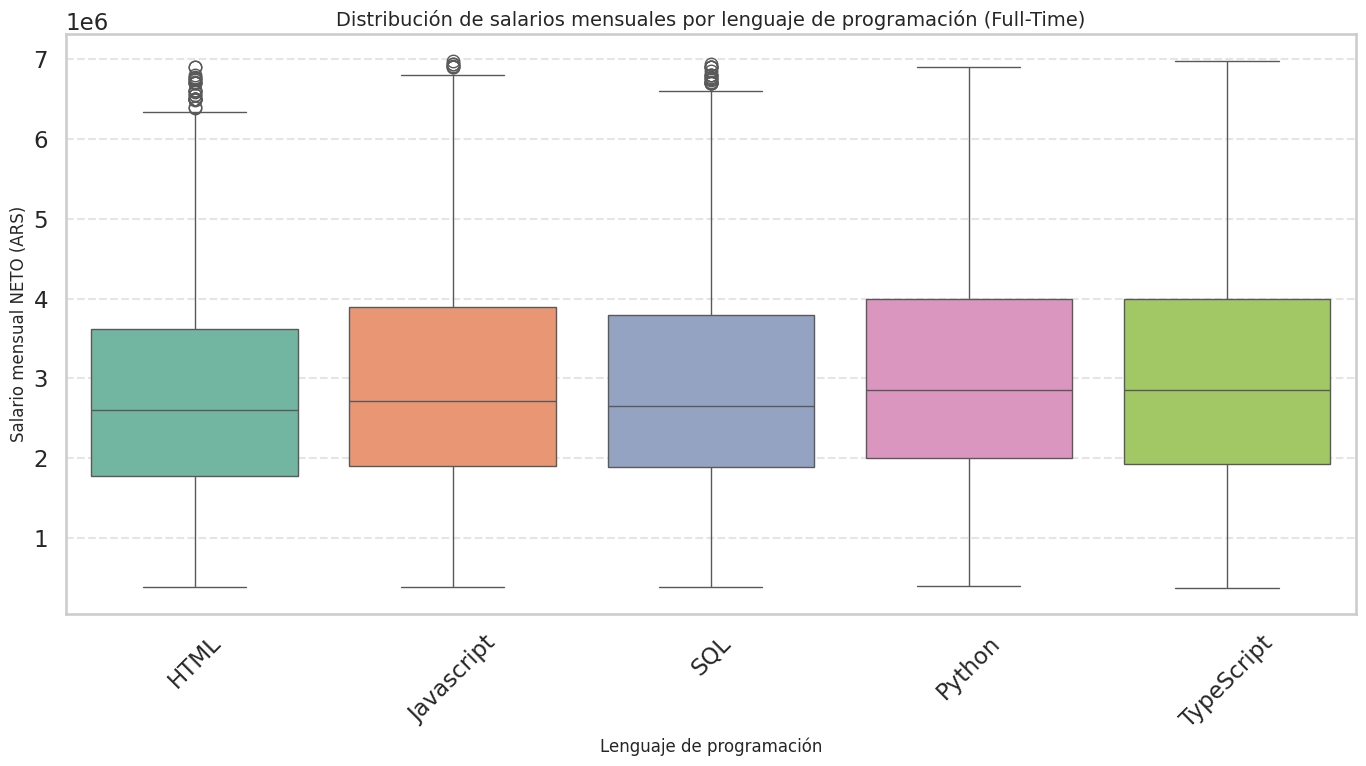

In [ ]:
# Lenguajes seleccionados
selected_languages = ['SQL','Javascript','Python','HTML','TypeScript']

# Expandir las filas por lenguaje
df_lang_salary = df_filtered[['tools_programming_languages', 'salary_monthly_NETO']].dropna()
df_lang_salary = df_lang_salary.assign(
    tools_programming_languages=df_lang_salary['tools_programming_languages'].str.split(', ')
).explode('tools_programming_languages')

# Filtrar por lenguajes seleccionados
df_lang_salary = df_lang_salary[df_lang_salary['tools_programming_languages'].isin(selected_languages)]

# Renombrar para graficar
df_lang_salary = df_lang_salary.rename(columns={'tools_programming_languages': 'language', 'salary_monthly_NETO': 'salary'})

# Visualización: Boxplot
plt.figure(figsize=(14, 8))
seaborn.boxplot(data=df_lang_salary, x='language', y='salary', palette='Set2')


plt.xticks(rotation=45)
plt.title('Distribución de salarios mensuales por lenguaje de programación (Full-Time)', fontsize=14)
plt.ylabel('Salario mensual NETO (ARS)', fontsize=12)
plt.xlabel('Lenguaje de programación', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

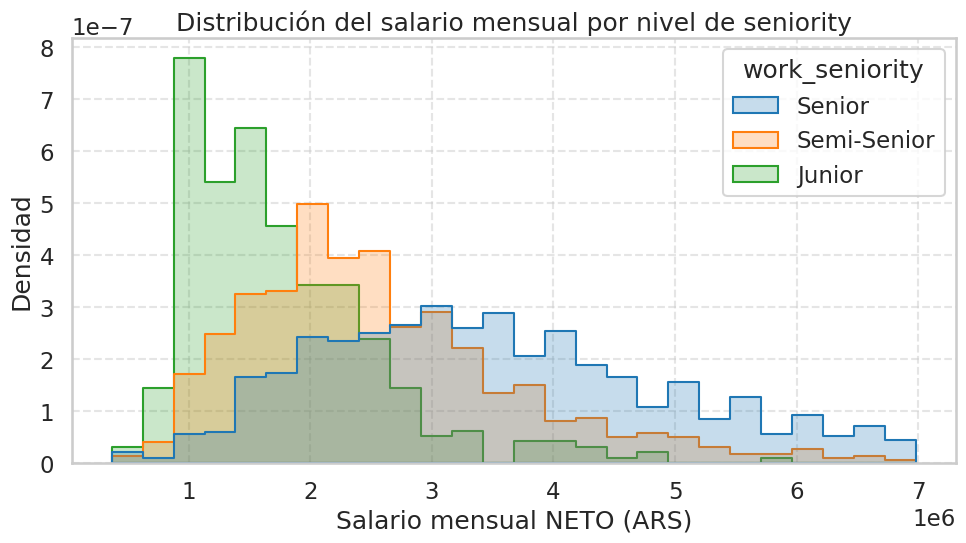

In [ ]:
plt.figure(figsize=(10, 6))
seaborn.histplot(data=df_filtered, x='salary_monthly_NETO', hue='work_seniority', element='step', stat='density', common_norm=False, palette='tab10')
plt.title('Distribución del salario mensual por nivel de seniority')
plt.xlabel('Salario mensual NETO (ARS)')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

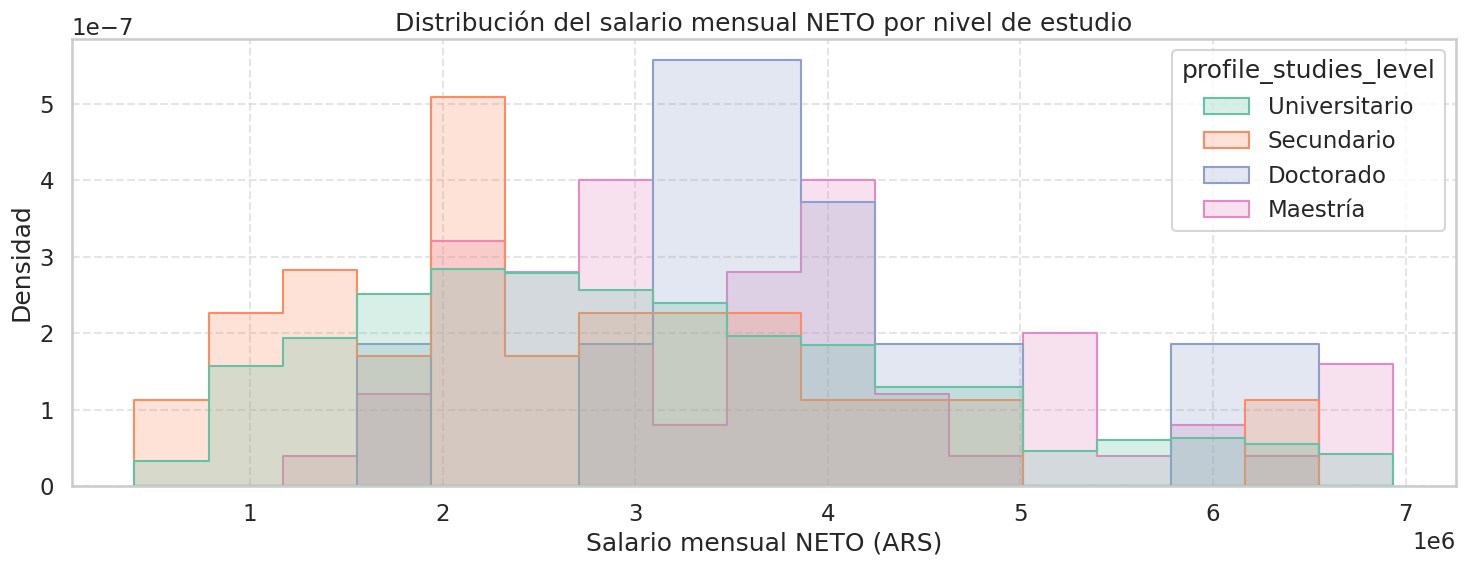

In [ ]:
# 👉 Elegís los niveles que querés analizar
niveles = ["Secundario", "Universitario", "Maestría", "Doctorado"]  # cambiá estos valores según necesites

# 👉 Filtrado
df_estudios = df_filtered[
    df_filtered["profile_studies_level"].isin(niveles)
]

# 👉 Gráfico (igual al tuyo, pero con el df filtrado)
plt.figure(figsize=(15, 6))
seaborn.histplot(
    data=df_estudios,
    x='salary_monthly_NETO',
    hue='profile_studies_level',
    element='step',
    stat='density',
    common_norm=False,
    palette='Set2'
)

plt.title('Distribución del salario mensual NETO por nivel de estudio')
plt.xlabel('Salario mensual NETO (ARS)')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


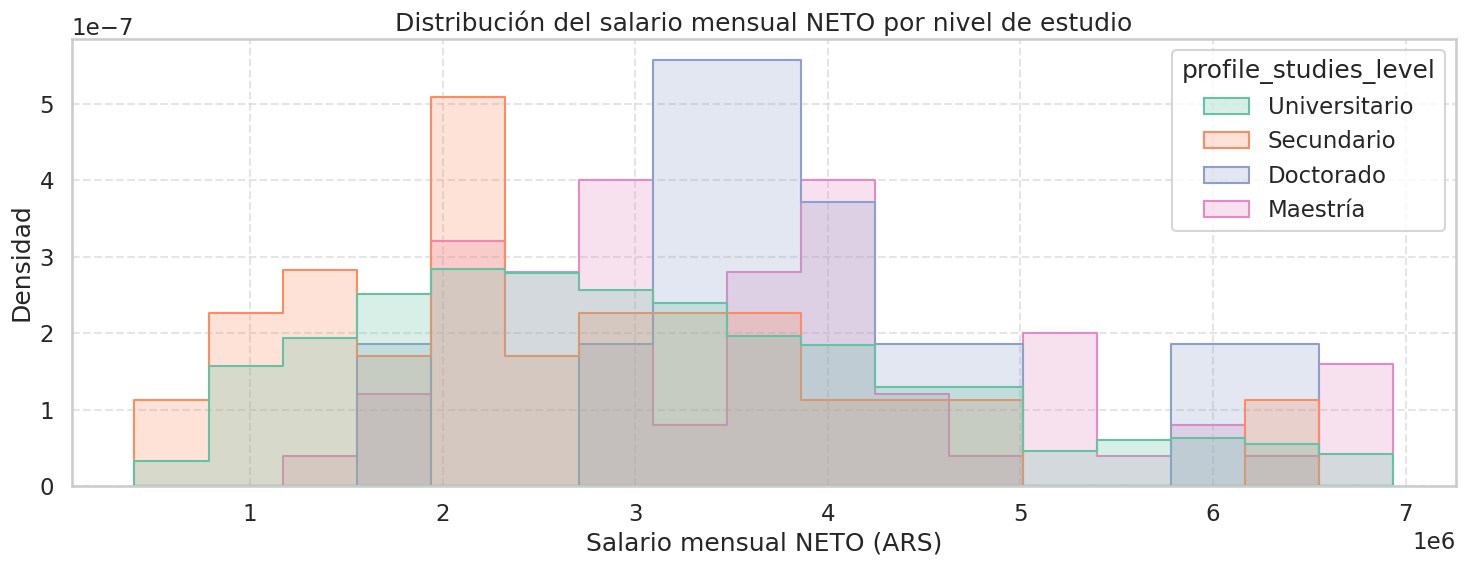

In [ ]:
plt.figure(figsize=(15, 6))
seaborn.histplot(data=df_estudios, x='salary_monthly_NETO', hue='profile_studies_level', element='step', stat='density', common_norm=False, palette='Set2')
plt.title('Distribución del salario mensual NETO por nivel de estudio')
plt.xlabel('Salario mensual NETO (ARS)')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#VER NO SE SI AGREGARLO PARA

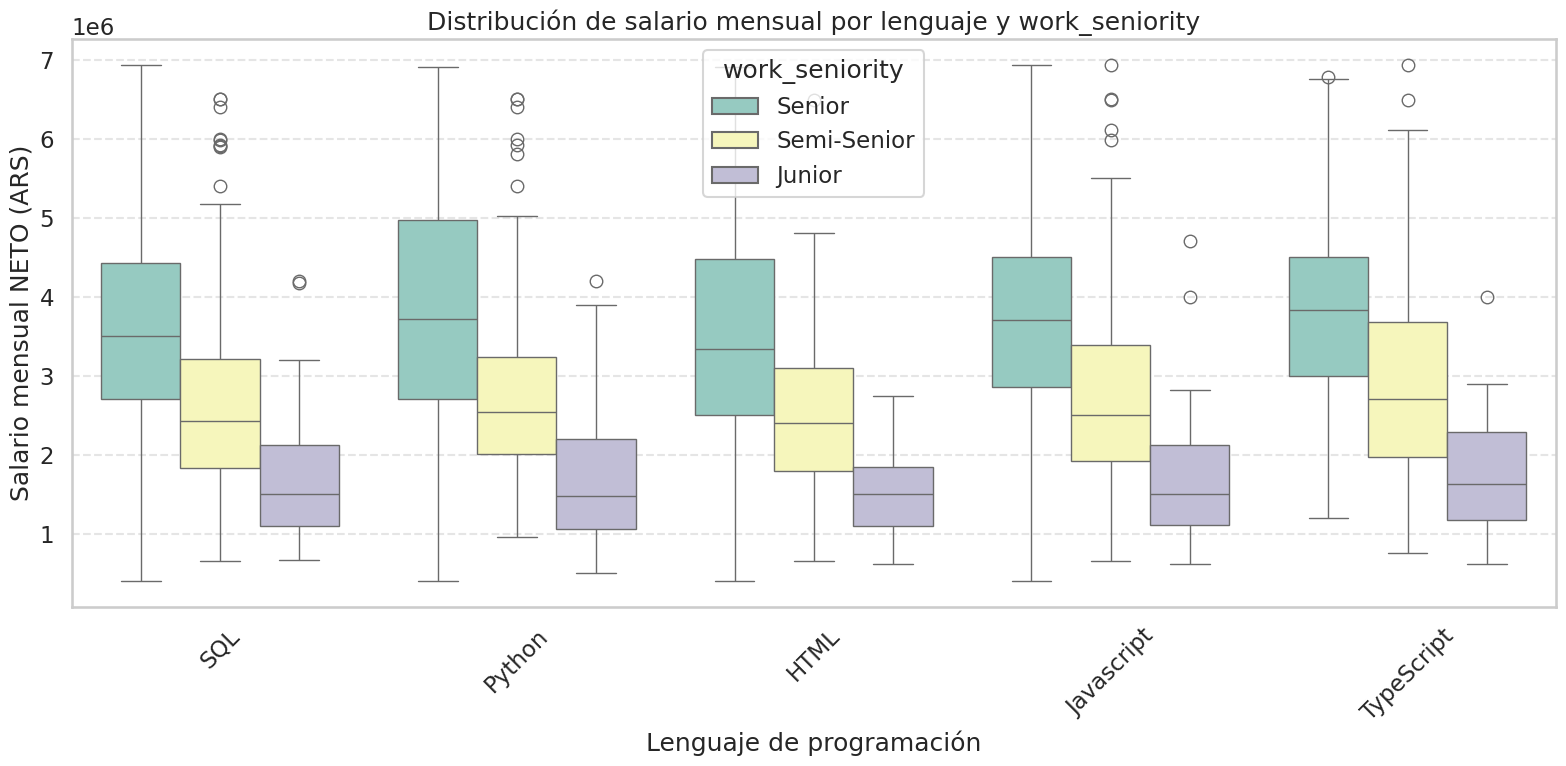

In [ ]:
# Expandir lenguajes
df_lang_salary_cat = df_estudios[['tools_programming_languages', 'salary_monthly_NETO', 'work_seniority']].dropna()
df_lang_salary_cat = df_lang_salary_cat.assign(
    tools_programming_languages=df_lang_salary_cat['tools_programming_languages'].str.split(', ')
).explode('tools_programming_languages')

# Filtrar lenguajes top 10
selected_languages = ['Javascript', 'Python', 'TypeScript','HTML', 'SQL']
df_lang_salary_cat = df_lang_salary_cat[df_lang_salary_cat['tools_programming_languages'].isin(selected_languages)]

# Renombrar columnas para graficar
df_lang_salary_cat = df_lang_salary_cat.rename(columns={
    'tools_programming_languages': 'language',
    'salary_monthly_NETO': 'salary',
    'work_seniority': 'work_seniority'
})

# Boxplot
plt.figure(figsize=(16, 8))
seaborn.boxplot(data=df_lang_salary_cat, x='language', y='salary', hue='work_seniority', palette='Set3')
plt.xticks(rotation=45)
plt.title('Distribución de salario mensual por lenguaje y work_seniority')
plt.xlabel('Lenguaje de programación')
plt.ylabel('Salario mensual NETO (ARS)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Ejercicio 2. Densidades y varias variables

/tmp/ipykernel_12974/665179629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.boxplot(x="work_seniority", y="salary_monthly_NETO", data=df_estudios, palette="pastel")


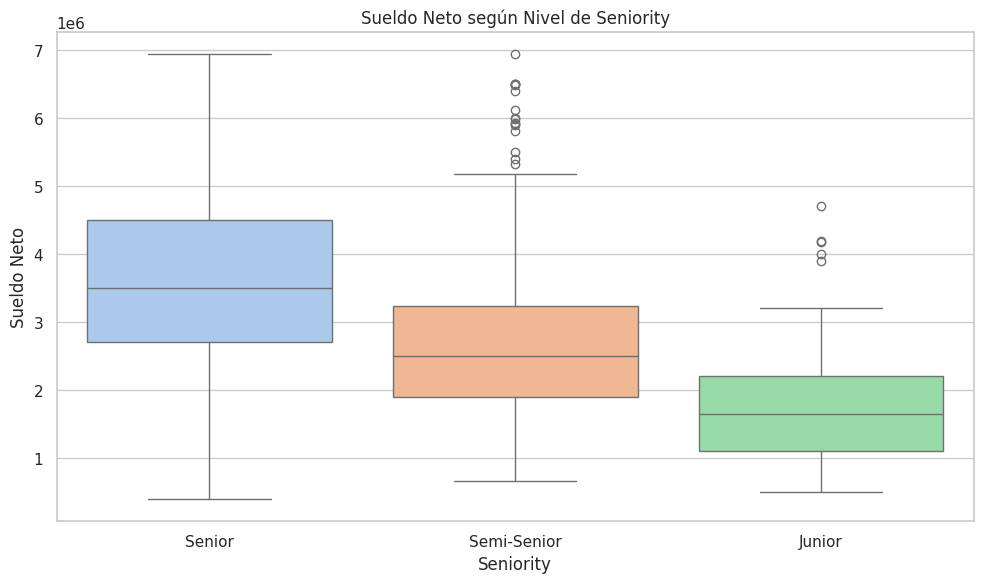

In [ ]:
# 2. Boxplot de sueldo por seniority
plt.figure()
seaborn.boxplot(x="work_seniority", y="salary_monthly_NETO", data=df_estudios, palette="pastel")
plt.title("Sueldo Neto según Nivel de Seniority")
plt.xlabel("Seniority")
plt.ylabel("Sueldo Neto")
plt.tight_layout()
plt.show()


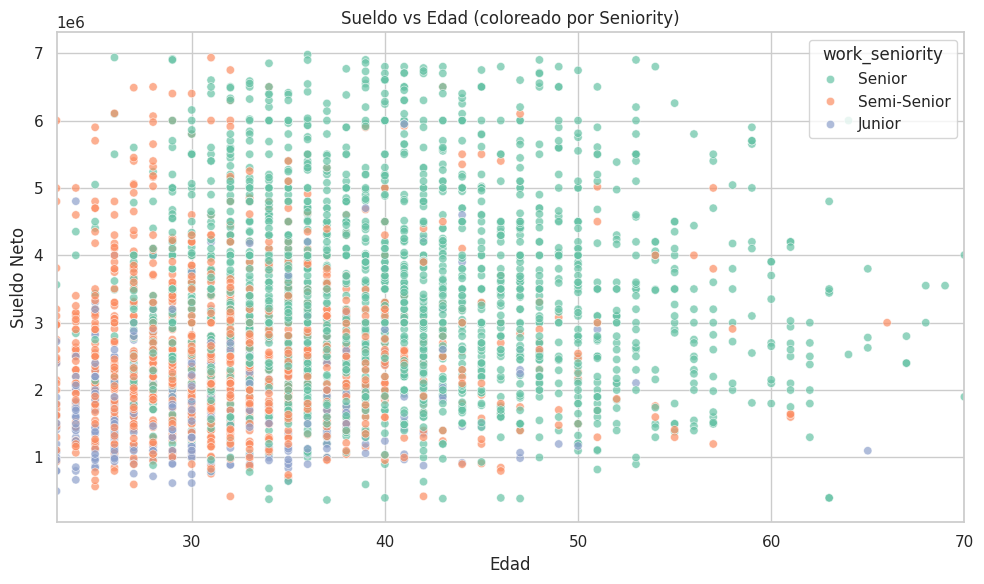

In [ ]:
plt.figure()
seaborn.scatterplot(
    data=df_filtered,
    x="profile_age",
    y="salary_monthly_NETO",
    hue="work_seniority",
    palette="Set2",
    alpha=0.7
)
plt.title("Sueldo vs Edad (coloreado por Seniority)")
plt.xlabel("Edad")
plt.ylabel("Sueldo Neto")
plt.xlim(23, 70)
plt.tight_layout()
plt.show()

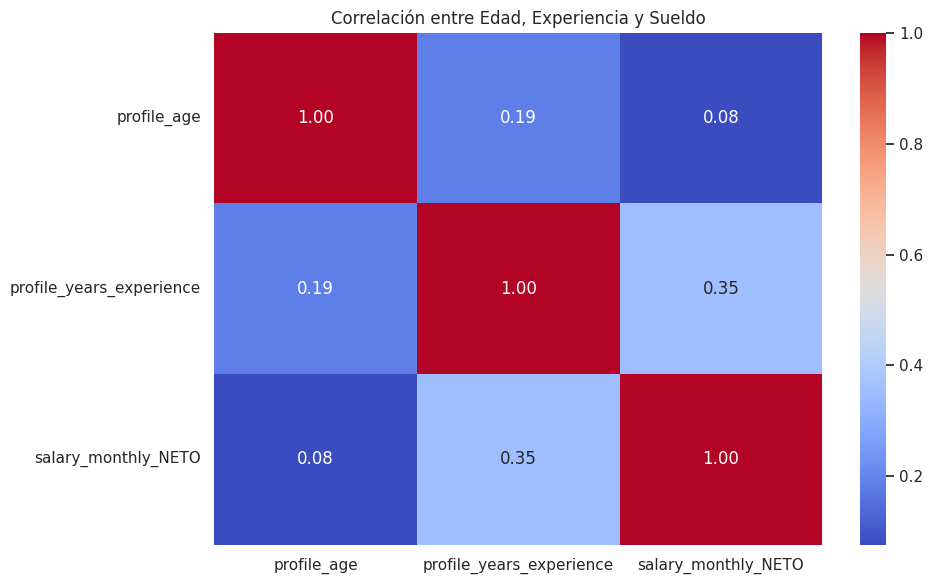

In [ ]:
# 5. Mapa de calor de correlaciones
plt.figure()
corr = df_estudios[["profile_age", "profile_years_experience", "salary_monthly_NETO"]].corr()
seaborn.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre Edad, Experiencia y Sueldo")
plt.tight_layout()
plt.show()

# b) Asociación

Correlación de Pearson: 0.1559


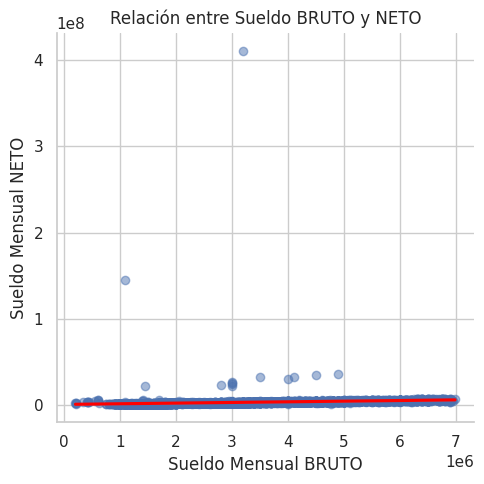

Coeficiente R² de la regresión lineal: 0.0243
Pendiente (coeficiente): 0.75
Intercepto: 530726.23


In [ ]:
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression


# Filtro: valores válidos, full-time, sin extremos
df_bruto_neto = df[
    (df["work_dedication"] == "Full-Time") &
    (df["salary_monthly_NETO"].notna()) &
    (df["salary_monthly_BRUTO"].notna()) &
    (df["salary_monthly_NETO"] > 297000) &
    (df["salary_monthly_NETO"] > 700000) &
    (df["salary_monthly_BRUTO"] < 7000000)
][["salary_monthly_NETO", "salary_monthly_BRUTO"]]

# Calcular correlaciones
pearson_corr, _ = pearsonr(df_bruto_neto["salary_monthly_BRUTO"], df_bruto_neto["salary_monthly_NETO"])
#spearman_corr, _ = spearmanr(df_bruto_neto["salary_monthly_BRUTO"], df_bruto_neto["salary_monthly_NETO"])

print(f"Correlación de Pearson: {pearson_corr:.4f}")
#print(f"Correlación de Spearman: {spearman_corr:.4f}")

# Gráfico de dispersión + línea de regresión
seaborn.lmplot(
    data=df_bruto_neto,
    x="salary_monthly_BRUTO",
    y="salary_monthly_NETO",
    line_kws={"color": "red"},
    scatter_kws={"alpha": 0.5}
)
plt.title("Relación entre Sueldo BRUTO y NETO")
plt.xlabel("Sueldo Mensual BRUTO")
plt.ylabel("Sueldo Mensual NETO")
plt.tight_layout()
plt.show()

# Regresión lineal simple
X = df_bruto_neto["salary_monthly_BRUTO"].values.reshape(-1, 1)
y = df_bruto_neto["salary_monthly_NETO"].values
model = LinearRegression().fit(X, y)

print(f"Coeficiente R² de la regresión lineal: {model.score(X, y):.4f}")
print(f"Pendiente (coeficiente): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")


#c)

In [ ]:
# Verificamos los valores únicos en la columna 'profile_studies_level'
df['profile_studies_level'].value_counts()

,count
profile_studies_level,
Universitario,1175
Terciario,272
Maestría,108
Posgrado/Especialización,108
Secundario,65
Doctorado,27
Posdoctorado,6


In [ ]:
# Elegimos las dos subpoblaciones: Universitario vs Terciario
niveles = ["Universitario", "Terciario"]
df_estudios = df_netos[df_netos["profile_studies_level"].isin(niveles)]

# Histograma comparativo con densidad
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_estudios,
    x="salary_monthly_NETO",
    hue="profile_studies_level",
    kde=True,
    bins=30,
    palette="Set2",
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Distribución del sueldo NETO según nivel de estudios")
plt.xlabel("Sueldo Mensual Neto")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

# Estadísticas por grupo
medidas = df_estudios.groupby("profile_studies_level")["salary_monthly_NETO"].agg(
    media="mean",
    mediana="median",
    desviacion_std="std",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    conteo="count"
)
medidas["IQR"] = medidas["q3"] - medidas["q1"]
medidas = medidas[["media", "mediana", "desviacion_std", "IQR", "conteo"]]

medidas

NameError: name 'df_netos' is not defined

El grupo de estudios con estudios universitarios tiene sueldos promedio y mediana más altas.

El salario mensual neto depende del nivel educativo. Las personas con estudios universitarios tienden a ganar más y tienen una mayor variabilidad salarial.

Esto indica que ambas variables no son independientes, y que el nivel de estudios debe mantenerse en la encuesta y en los modelos analíticos posteriores